<a href="https://colab.research.google.com/github/soaresgaab/TestePraticoProjedata/blob/main/Mestrado_UFMA_APE_Microdados_2021_a_2024_(Analise_Exploratoria).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# --> Junção dos Dataset

In [8]:
import os
import pandas as pd
import glob

from google.colab import drive
drive.mount('/content/drive')

caminho_limpos = '/content/drive/MyDrive/Mestrado UFMA/Análiticas de Aprendizagem/Dados Censo Superior Limpos/'
padrao_busca = os.path.join(caminho_limpos, '*.csv')
arquivos_csv = glob.glob(padrao_busca)

arquivos_csv = [arq for arq in arquivos_csv if 'SUPER_DATASET' not in arq]

if len(arquivos_csv) == 0:
    print("❌ Nenhum arquivo encontrado! Verifique se os nomes e o caminho estão corretos.")
else:
    print(f"Foram encontrados {len(arquivos_csv)} arquivos para unir:")

    lista_dfs = []
    for arquivo in arquivos_csv:
        print(f" - Lendo: {os.path.basename(arquivo)}")
        lista_dfs.append(pd.read_csv(arquivo))

    df_super = pd.concat(lista_dfs, ignore_index=True)
    nome_arquivo_final = 'SUPER_DATASET_COMPUTACAO_2020_2024.csv'
    caminho_salvar = os.path.join(caminho_limpos, nome_arquivo_final)
    df_super.to_csv(caminho_salvar, index=False, encoding='utf-8-sig')

    print(f"\n✅ SUCESSO! O Super Dataset foi salvo com {df_super.shape[0]} linhas.")
    print(f"📁 Salvo em: {caminho_salvar}")

Mounted at /content/drive
Foram encontrados 5 arquivos para unir:
 - Lendo: df_computacao_limpo_2020.csv
 - Lendo: df_computacao_limpo_2021.csv
 - Lendo: df_computacao_limpo_2022.csv
 - Lendo: df_computacao_limpo_2023.csv
 - Lendo: df_computacao_limpo_2024.csv

✅ SUCESSO! O Super Dataset foi salvo com 227003 linhas.
📁 Salvo em: /content/drive/MyDrive/Mestrado UFMA/Análiticas de Aprendizagem/Dados Censo Superior Limpos/SUPER_DATASET_COMPUTACAO_2020_2024.csv


# --> Visualização da tabela Descritiva

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

caminho_super = '/content/drive/MyDrive/Mestrado UFMA/Análiticas de Aprendizagem/Dados Censo Superior Limpos/SUPER_DATASET_COMPUTACAO_2020_2024.csv'
df_super = pd.read_csv(caminho_super)

print("=== TABELA 1: ESTATÍSTICA DESCRITIVA GERAL (Brasil 2020-2024) ===")
estatisticas = df_super[['PERC_ING_FEM', 'PERC_MAT_FEM', 'PERC_CONC_FEM']].describe().loc[['mean', '50%', 'std']]
estatisticas = estatisticas.rename(index={'50%': 'mediana'})
display(estatisticas.round(2))

print("\n=== TABELA 2: MÉDIAS DE PARTICIPAÇÃO FEMININA POR REGIÃO ===")
estatisticas_regiao = df_super.groupby('NO_REGIAO')[['PERC_ING_FEM', 'PERC_MAT_FEM', 'PERC_CONC_FEM']].mean().round(2)
display(estatisticas_regiao)

=== TABELA 1: ESTATÍSTICA DESCRITIVA GERAL (Brasil 2020-2024) ===


,PERC_ING_FEM,PERC_MAT_FEM,PERC_CONC_FEM
mean,16.26,15.42,3.51
mediana,0.00,0.00,0.00
std,28.51,27.30,14.90



=== TABELA 2: MÉDIAS DE PARTICIPAÇÃO FEMININA POR REGIÃO ===


,PERC_ING_FEM,PERC_MAT_FEM,PERC_CONC_FEM
NO_REGIAO,,,
CENTRO-OESTE,15.14,14.52,3.14
NORDESTE,14.30,13.51,2.81
NORTE,15.57,14.45,2.63
SUDESTE,17.47,16.64,4.08
SUL,16.16,15.26,3.41


# Gráfico A - Evolução Longitudinal

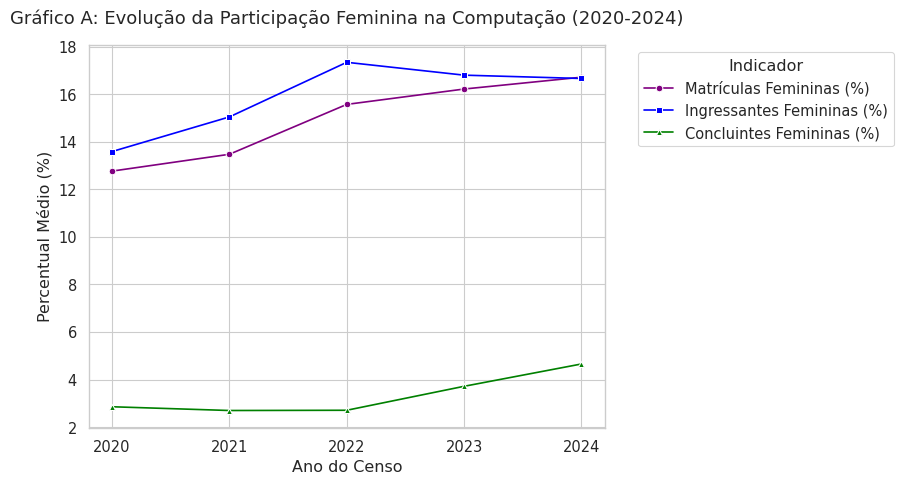

In [10]:
plt.figure(figsize=(9, 5))

sns.lineplot(data=df_super, x='ANO_CENSO', y='PERC_MAT_FEM', marker='o', color='purple', label='Matrículas Femininas (%)', errorbar=None)
sns.lineplot(data=df_super, x='ANO_CENSO', y='PERC_ING_FEM', marker='s', color='blue', label='Ingressantes Femininas (%)', errorbar=None)
sns.lineplot(data=df_super, x='ANO_CENSO', y='PERC_CONC_FEM', marker='^', color='green', label='Concluintes Femininas (%)', errorbar=None)

plt.title('Gráfico A: Evolução da Participação Feminina na Computação (2020-2024)', fontsize=13, pad=15)
plt.ylabel('Percentual Médio (%)')
plt.xlabel('Ano do Censo')
plt.xticks([2020, 2021, 2022, 2023, 2024])
plt.legend(title="Indicador", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Gráfico B - Comparação Regional

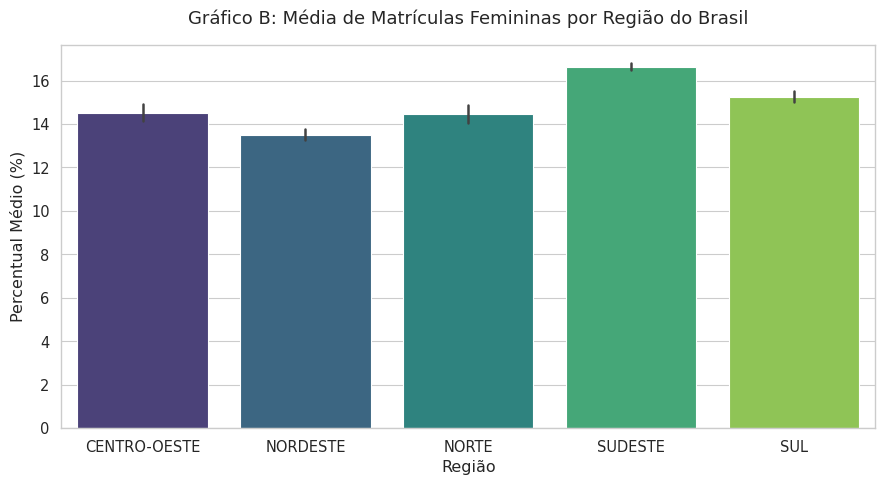

In [11]:
plt.figure(figsize=(9, 5))

sns.barplot(data=df_super, x='NO_REGIAO', y='PERC_MAT_FEM', hue='NO_REGIAO', palette='viridis', legend=False)

plt.title('Gráfico B: Média de Matrículas Femininas por Região do Brasil', fontsize=13, pad=15)
plt.ylabel('Percentual Médio (%)')
plt.xlabel('Região')

plt.tight_layout()
plt.show()

# Gráfico C — Instituições Públicas vs. Privadas

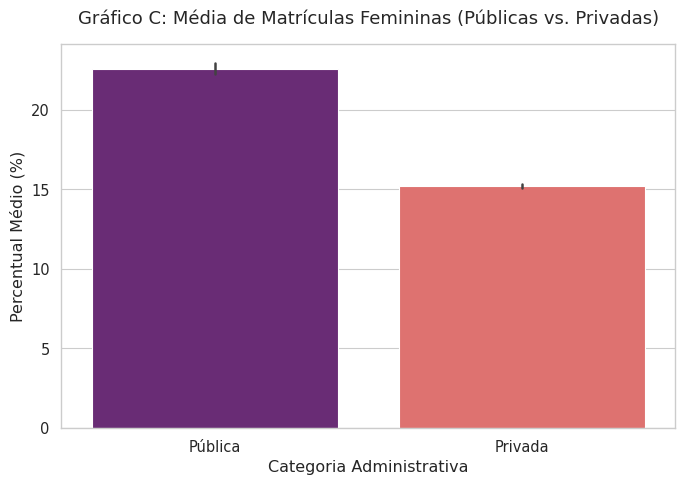

In [12]:
plt.figure(figsize=(7, 5))

sns.barplot(data=df_super, x='TIPO_INSTITUICAO', y='PERC_MAT_FEM', hue='TIPO_INSTITUICAO', palette='magma', legend=False)

plt.title('Gráfico C: Média de Matrículas Femininas (Públicas vs. Privadas)', fontsize=13, pad=15)
plt.ylabel('Percentual Médio (%)')
plt.xlabel('Categoria Administrativa')

plt.tight_layout()
plt.show()

# --> Dados e geração de text para o overleaf

In [13]:
print("--- CARACTERÍSTICAS PARA A SEÇÃO 2 ---")
print(f"Total de linhas (registros): {df_super.shape[0]}")
print(f"Total de colunas (variáveis): {df_super.shape[1]}")
print(f"Variáveis numéricas: {len(df_super.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"Variáveis categóricas/texto: {len(df_super.select_dtypes(include=['object']).columns)}")
print(f"Registros com valores faltantes: {df_super.isnull().any(axis=1).sum()}")
print(f"Registros duplicados: {df_super.duplicated().sum()}")

--- CARACTERÍSTICAS PARA A SEÇÃO 2 ---
Total de linhas (registros): 227003
Total de colunas (variáveis): 18
Variáveis numéricas: 13
Variáveis categóricas/texto: 5
Registros com valores faltantes: 0
Registros duplicados: 51316


In [14]:
amostra_completa = df_super.head(5)
print(amostra_completa.to_latex(index=False, float_format="%.2f"))

\begin{tabular}{llrllrrrrrrrrrrrlr}
\toprule
NO_REGIAO & SG_UF & CO_IES & NO_CURSO & NO_CINE_AREA_GERAL & TP_MODALIDADE_ENSINO & QT_ING & QT_ING_FEM & QT_MAT & QT_MAT_FEM & QT_CONC & QT_CONC_FEM & PERC_ING_FEM & PERC_MAT_FEM & PERC_CONC_FEM & TP_CATEGORIA_ADMINISTRATIVA & TIPO_INSTITUICAO & ANO_CENSO \\
\midrule
CENTRO-OESTE & DF & 2 & CIÊNCIA DA COMPUTAÇÃO & Computação e Tecnologias da Informação e Comunicação (TIC) & 1 & 86 & 16 & 427 & 59 & 36 & 5 & 18.60 & 13.82 & 13.89 & 1 & Pública & 2020 \\
CENTRO-OESTE & DF & 2 & ENGENHARIA DE COMPUTAÇÃO & Computação e Tecnologias da Informação e Comunicação (TIC) & 1 & 76 & 5 & 378 & 45 & 40 & 5 & 6.58 & 11.90 & 12.50 & 1 & Pública & 2020 \\
CENTRO-OESTE & DF & 2 & ENGENHARIA DE SOFTWARE & Computação e Tecnologias da Informação e Comunicação (TIC) & 1 & 14 & 2 & 828 & 109 & 64 & 12 & 14.29 & 13.16 & 18.75 & 1 & Pública & 2020 \\
CENTRO-OESTE & DF & 322 & ANÁLISE E DESENVOLVIMENTO DE SISTEMAS & Computação e Tecnologias da Informação e Comunicaç

In [15]:
colunas_principais = ['ANO_CENSO', 'NO_REGIAO', 'NO_CURSO', 'PERC_MAT_FEM']
amostra_limpa = df_super[colunas_principais].head(5)
print(amostra_limpa.to_latex(index=False, float_format="%.2f"))

\begin{tabular}{rllr}
\toprule
ANO_CENSO & NO_REGIAO & NO_CURSO & PERC_MAT_FEM \\
\midrule
2020 & CENTRO-OESTE & CIÊNCIA DA COMPUTAÇÃO & 13.82 \\
2020 & CENTRO-OESTE & ENGENHARIA DE COMPUTAÇÃO & 11.90 \\
2020 & CENTRO-OESTE & ENGENHARIA DE SOFTWARE & 13.16 \\
2020 & CENTRO-OESTE & ANÁLISE E DESENVOLVIMENTO DE SISTEMAS & 13.47 \\
2020 & CENTRO-OESTE & CIÊNCIA DA COMPUTAÇÃO & 8.72 \\
\bottomrule
\end{tabular}



# --> Análise descritiva Univariada

In [16]:
vars_num = ['PERC_ING_FEM', 'PERC_MAT_FEM', 'PERC_CONC_FEM']
desc = df_super[vars_num].describe(percentiles=[.25, .75]).T
desc['skew'] = df_super[vars_num].skew() # Assimetria
print(desc[['mean', '50%', 'std', 'min', 'max', '25%', '75%', 'skew']])

for col in ['NO_REGIAO', 'TIPO_INSTITUICAO']:
    freq = df_super[col].value_counts().reset_index()
    freq.columns = ['Categoria', 'Absoluta']
    freq['Relativa (%)'] = (freq['Absoluta'] / len(df_super)) * 100
    print(f"\n--- Tabela para {col} ---")
    print(freq)

                    mean  50%        std  min    max  25%        75%      skew
PERC_ING_FEM   16.258513  0.0  28.511336  0.0  100.0  0.0  23.444976  1.953156
PERC_MAT_FEM   15.419920  0.0  27.296250  0.0  100.0  0.0  20.454545  2.079877
PERC_CONC_FEM   3.512189  0.0  14.895042  0.0  100.0  0.0   0.000000  5.244855

--- Tabela para NO_REGIAO ---
      Categoria  Absoluta  Relativa (%)
0       SUDESTE    100371     44.215715
1           SUL     48119     21.197517
2      NORDESTE     42815     18.860984
3  CENTRO-OESTE     19143      8.432928
4         NORTE     16555      7.292855

--- Tabela para TIPO_INSTITUICAO ---
  Categoria  Absoluta  Relativa (%)
0   Privada    221161     97.426466
1   Pública      5842      2.573534


<Figure size 1500x500 with 0 Axes>

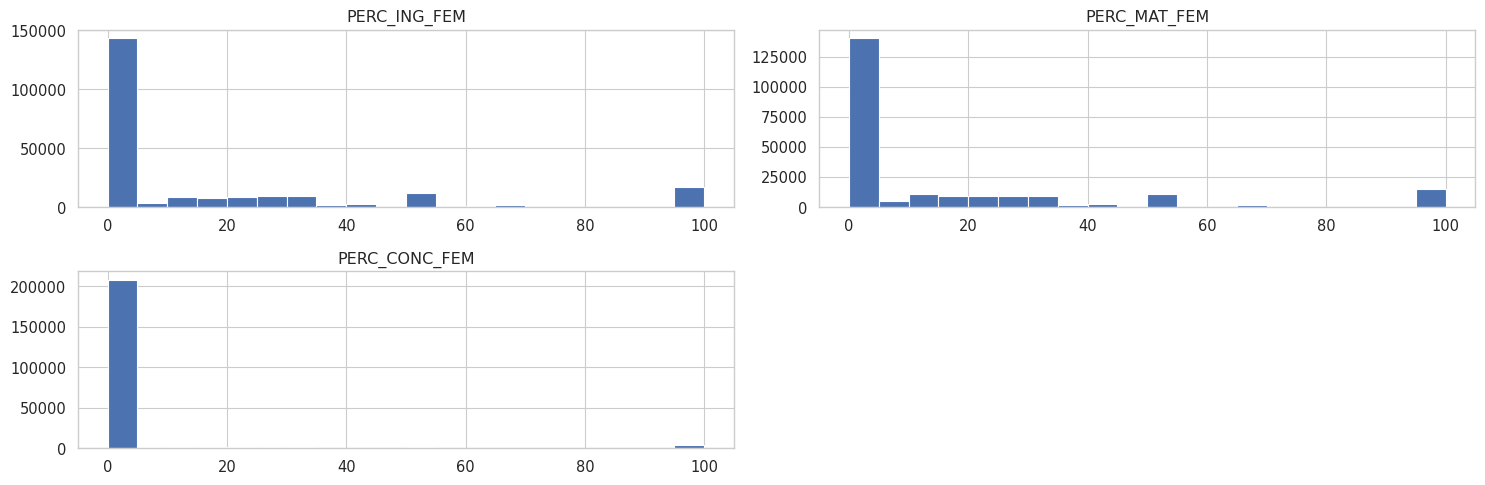

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))
df_super[['PERC_ING_FEM', 'PERC_MAT_FEM', 'PERC_CONC_FEM']].hist(bins=20, figsize=(15, 5))
plt.tight_layout()
plt.savefig('hist_fem.png')

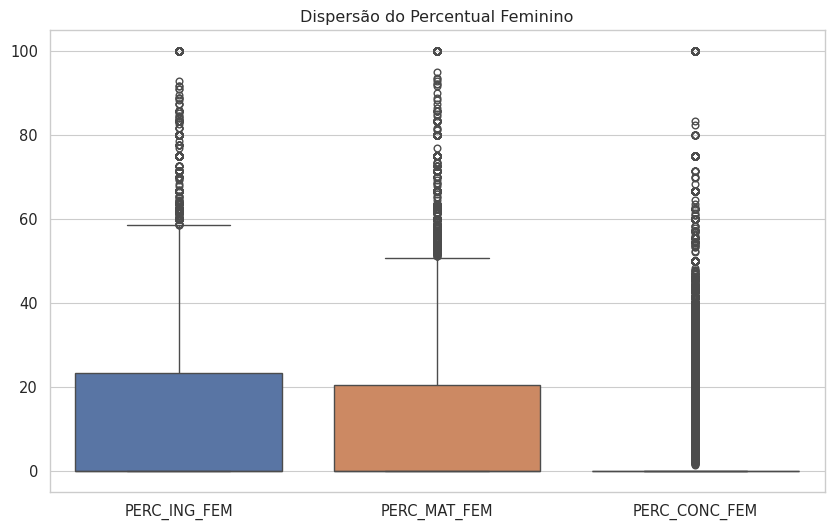

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_super[['PERC_ING_FEM', 'PERC_MAT_FEM', 'PERC_CONC_FEM']])
plt.title('Dispersão do Percentual Feminino')
plt.savefig('box_fem.png')

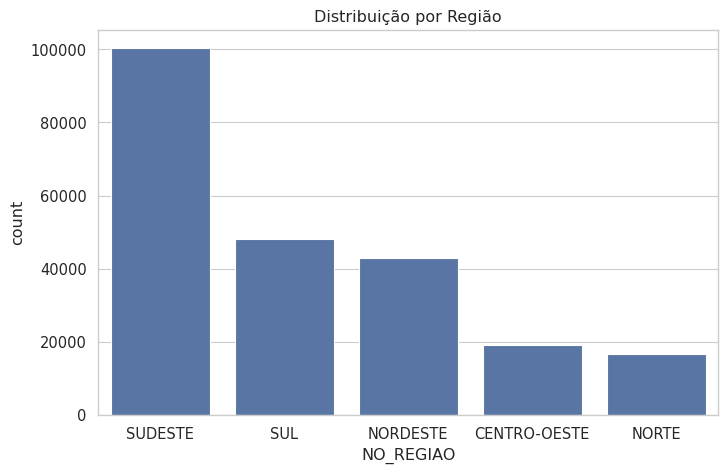

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_super, x='NO_REGIAO', order=df_super['NO_REGIAO'].value_counts().index)
plt.title('Distribuição por Região')
plt.savefig('bar_regiao.png')

# --> Análise Descritiva Bivariada e Exploratória

--- Tabela 6.2: Correlação Spearman ---
               PERC_ING_FEM  PERC_MAT_FEM  PERC_CONC_FEM
PERC_ING_FEM       1.000000      0.659996       0.159404
PERC_MAT_FEM       0.659996      1.000000       0.319404
PERC_CONC_FEM      0.159404      0.319404       1.000000


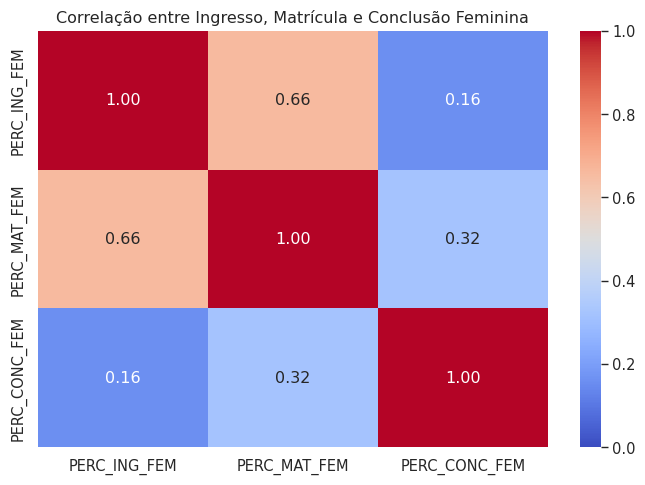

In [20]:
correlacao = df_super[['PERC_ING_FEM', 'PERC_MAT_FEM', 'PERC_CONC_FEM']].corr(method='spearman')
print("--- Tabela 6.2: Correlação Spearman ---")
print(correlacao)

plt.figure(figsize=(7, 5))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1)
plt.title("Correlação entre Ingresso, Matrícula e Conclusão Feminina")
plt.tight_layout()
plt.savefig('heatmap_corr.png')


--- Tabela 6.3: Estatísticas de Conclusão por Região ---
      NO_REGIAO      mean  median        std
0  CENTRO-OESTE  3.142937     0.0  13.910828
1      NORDESTE  2.808157     0.0  13.405212
2         NORTE  2.631203     0.0  13.185413
3       SUDESTE  4.076956     0.0  15.907576
4           SUL  3.410568     0.0  14.855815


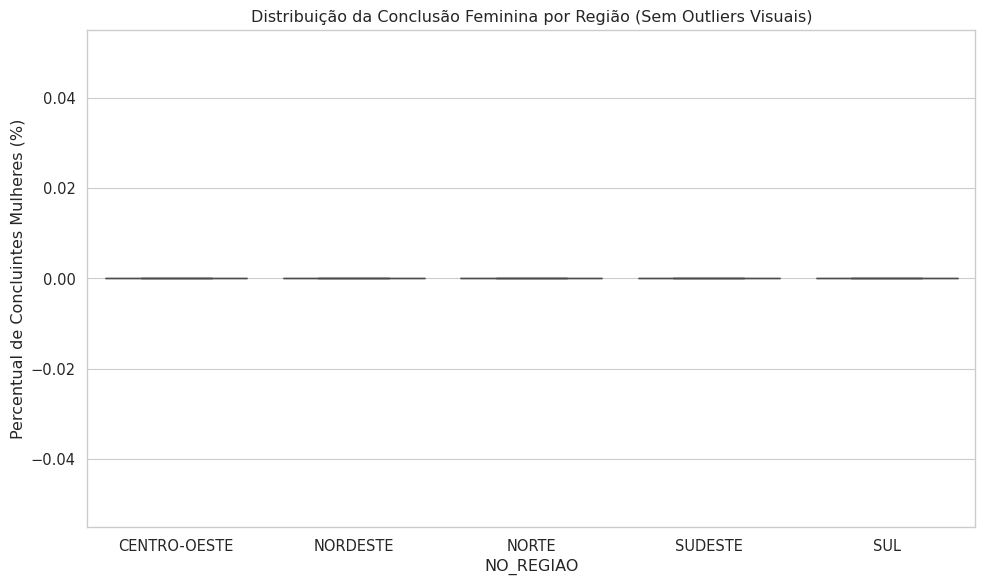

In [21]:
media_regiao = df_super.groupby('NO_REGIAO')['PERC_CONC_FEM'].agg(['mean', 'median', 'std']).reset_index()
print("\n--- Tabela 6.3: Estatísticas de Conclusão por Região ---")
print(media_regiao)

plt.figure(figsize=(10, 6))
sns.boxplot(x='NO_REGIAO', y='PERC_CONC_FEM', data=df_super, showfliers=False, hue='NO_REGIAO', legend=False)
plt.title("Distribuição da Conclusão Feminina por Região (Sem Outliers Visuais)")
plt.ylabel("Percentual de Concluintes Mulheres (%)")
plt.tight_layout()
plt.savefig('box_regiao_conc.png')


--- Tabela 6.4: Proporção (Tabela de Contingência) ---
TIPO_INSTITUICAO    Privada   Pública
NO_REGIAO                            
CENTRO-OESTE      97.241812  2.758188
NORDESTE          97.921289  2.078711
NORTE             98.248263  1.751737
SUDESTE           96.497992  3.502008
SUL               98.713606  1.286394


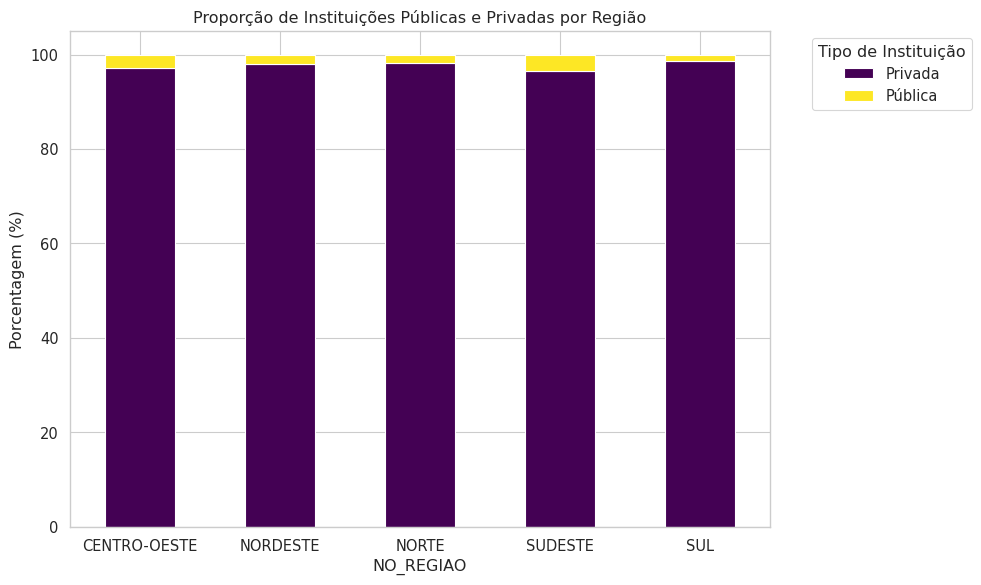

In [22]:
crosstab_cat = pd.crosstab(df_super['NO_REGIAO'], df_super['TIPO_INSTITUICAO'], normalize='index') * 100
print("\n--- Tabela 6.4: Proporção (Tabela de Contingência) ---")
print(crosstab_cat)

crosstab_cat.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title("Proporção de Instituições Públicas e Privadas por Região")
plt.ylabel("Porcentagem (%)")
plt.xticks(rotation=0)
plt.legend(title='Tipo de Instituição', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('bar_cat_cat.png')